# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-18] Epoch   1/100 | LR: 1.00e-04 | train loss 1.1298 acc 0.529 | val loss 0.7420 acc 0.734 *


[ResNet-18] Epoch   2/100 | LR: 1.00e-04 | train loss 0.6387 acc 0.715 | val loss 0.5674 acc 0.754 *


[ResNet-18] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4587 acc 0.780 | val loss 0.4679 acc 0.764 *


[ResNet-18] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3511 acc 0.806 | val loss 0.4846 acc 0.764


...

[ResNet-18] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1515 acc 0.924 | val loss 0.4784 acc 0.828


[ResNet-18] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1377 acc 0.937 | val loss 0.4584 acc 0.847


[ResNet-18] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0885 acc 0.963 | val loss 0.4287 acc 0.842


[ResNet-18] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0686 acc 0.959 | val loss 0.4040 acc 0.852


[ResNet-18] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0769 acc 0.963 | val loss 0.3969 acc 0.862

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ResNet-18] Restored best checkpoint (val loss = 0.3834)


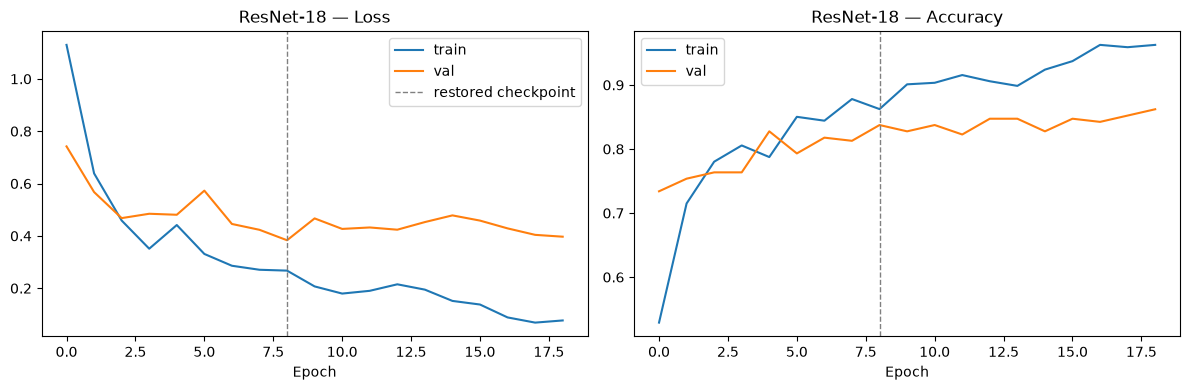

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.604


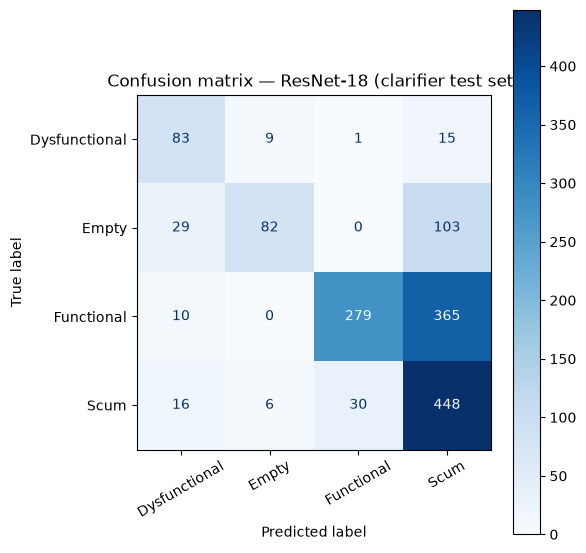

               precision    recall  f1-score   support

Dysfunctional      0.601     0.769     0.675       108
        Empty      0.845     0.383     0.527       214
   Functional      0.900     0.427     0.579       654
         Scum      0.481     0.896     0.626       500

     accuracy                          0.604      1476
    macro avg      0.707     0.619     0.602      1476
 weighted avg      0.728     0.604     0.594      1476



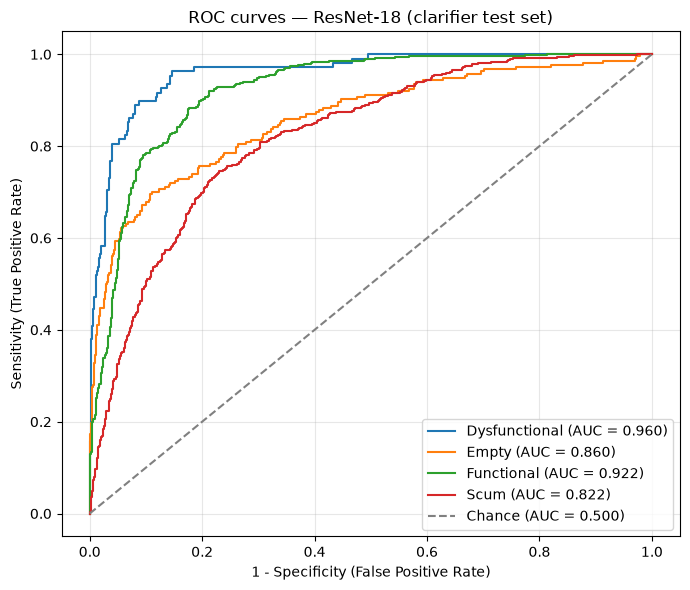

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.960
  Empty          : 0.860
  Functional     : 0.922
  Scum           : 0.822

Mean AUC (over 4/4 classes with test examples): 0.891


(np.float64(0.6043360433604336),
 {'Dysfunctional': 0.9602691141433832,
  'Empty': 0.8598167868833035,
  'Functional': 0.9217077018088202,
  'Scum': 0.8217786885245904})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_CapeFlats.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
